In [43]:

import pandas as pd
import numpy as np
 
SAMPLE_CSV = "../main/sample_house_full.csv"
OUTPUT_CSV = "../main/house_with_features.csv"  # overwrite in place (change if you want a separate file)
 
VOTEVIEW_URL = "https://voteview.com/static/data/out/members/HSall_members.csv"
CONGRESS_NUM = 118  # 118th Congress (2023-2025)
 
# %% [markdown]
# ## 1 · Load VoteView data
 
# %%
# Download the full VoteView members file (all congresses, ~50 MB)
# Filter immediately to 118th Congress to save memory
vv = pd.read_csv(VOTEVIEW_URL)
print(f"VoteView rows (all congresses): {len(vv):,}")
 
vv118 = vv[vv["congress"] == CONGRESS_NUM].copy()
print(f"118th Congress rows: {len(vv118)}")
print(f"Chambers: {vv118['chamber'].value_counts().to_dict()}")
 
vv118[["bioguide_id", "bioname", "chamber", "nominate_dim1", "nominate_dim2"]].head(10)

VoteView rows (all congresses): 51,053
118th Congress rows: 556
Chambers: {'House': 451, 'Senate': 105}


,bioguide_id,bioname,chamber,nominate_dim1,nominate_dim2
49950,R000575,"ROGERS, Mike Dennis",House,0.379,0.380
49951,S001185,"SEWELL, Terri",House,-0.402,0.394
49952,P000609,"PALMER, Gary James",House,0.674,0.116
49953,C001054,"CARL, Jerry L.",House,0.550,0.239
49954,M001212,"MOORE, Barry",House,0.643,-0.247
49955,S001220,"STRONG, Dale",House,0.602,0.368
49956,A000055,"ADERHOLT, Robert",House,0.405,0.469
49957,P000619,"PELTOLA, Mary Sattler",House,-0.138,0.378
49958,R000600,"RADEWAGEN, Aumua Amata Coleman",House,0.327,0.195
49959,G000551,"GRIJALVA, Raúl M.",House,-0.598,-0.264


In [44]:
print("DW-NOMINATE dim1 summary (118th Congress, House only):")
house_vv = vv118[vv118["chamber"] == "House"]
print(house_vv["nominate_dim1"].describe().round(3))
print(f"\nMissing dim1: {house_vv['nominate_dim1'].isna().sum()}")

DW-NOMINATE dim1 summary (118th Congress, House only):
count    451.000
mean       0.071
std        0.467
min       -0.771
25%       -0.384
50%        0.200
75%        0.508
max        0.894
Name: nominate_dim1, dtype: float64

Missing dim1: 0


In [45]:
sample = pd.read_csv(SAMPLE_CSV)
print(f"Sample rows: {len(sample)}")
 
# Select columns to merge from VoteView
vv_cols = vv118[["bioguide_id", "nominate_dim1", "nominate_dim2",
                  "nokken_poole_dim1", "nokken_poole_dim2",
                  "nominate_number_of_votes", "congress"]].copy()
vv_cols = vv_cols.rename(columns={"bioguide_id": "bioguide"})
 
# Drop duplicates (shouldn't be any, but just in case)
vv_cols = vv_cols.drop_duplicates("bioguide")
 
# Merge
sample = sample.merge(vv_cols, on="bioguide", how="left")
 
matched = sample["nominate_dim1"].notna().sum()
print(f"Matched: {matched} / {len(sample)}")
print(f"Missing DW-NOMINATE: {sample['nominate_dim1'].isna().sum()}")
 
# Show any unmatched
if sample["nominate_dim1"].isna().any():
    print("\nUnmatched members:")
    print(sample[sample["nominate_dim1"].isna()][["official_full", "bioguide", "party_code", "state"]].to_string())
 

Sample rows: 425
Matched: 422 / 425
Missing DW-NOMINATE: 3

Unmatched members:
         official_full bioguide party_code state
30         Wesley Bell  B001324          D    MO
91    Craig A. Goldman  G000601          D    TX
116  Alan S. Lowenthal  L000579          D    CA


In [46]:
sample["nominate_abs"] = sample["nominate_dim1"].abs()
 
print("Correlations with DW-NOMINATE dim1:")
print(f"  pct_small_donors vs nominate_dim1:    r = {sample['pct_small_donors'].corr(sample['nominate_dim1']):+.3f}")
print(f"  pct_small_donors vs |nominate_dim1|:  r = {sample['pct_small_donors'].corr(sample['nominate_abs']):+.3f}")
print()
 
# If you've already generated user_partisanship_summary.csv, merge and check
try:
    user = pd.read_csv("user_partisanship_summary.csv")
    user_with_nom = user.merge(
        sample[["bioguide", "nominate_dim1", "nominate_abs"]].dropna(),
        left_on="handle_lower",
        right_on=sample.loc[sample["bioguide"].notna(), "handle_lower"] if "handle_lower" in sample.columns else "bioguide",
        how="inner"
    )
    # Simpler approach: merge via sample as bridge
    bridge = sample[["twitter", "nominate_dim1", "nominate_abs"]].dropna(subset=["nominate_dim1"]).copy()
    bridge["handle_lower"] = bridge["twitter"].str.lower().str.strip()
    user_with_nom = user.merge(bridge[["handle_lower", "nominate_dim1", "nominate_abs"]], on="handle_lower", how="inner")
 
    print(f"Members with both text scores and DW-NOMINATE: {len(user_with_nom)}")
    print(f"  partisanship_score vs nominate_dim1:   r = {user_with_nom['partisanship_score'].corr(user_with_nom['nominate_dim1']):+.3f}")
    print(f"  partisanship_score vs |nominate_dim1|: r = {user_with_nom['partisanship_score'].corr(user_with_nom['nominate_abs']):+.3f}")
    print(f"  outrage_index vs |nominate_dim1|:      r = {user_with_nom['outrage_index'].corr(user_with_nom['nominate_abs']):+.3f}")
except FileNotFoundError:
    print("(user_partisanship_summary.csv not found — run the sentiment notebook first to validate)")

Correlations with DW-NOMINATE dim1:
  pct_small_donors vs nominate_dim1:    r = +0.125
  pct_small_donors vs |nominate_dim1|:  r = +0.179

(user_partisanship_summary.csv not found — run the sentiment notebook first to validate)


Saved → ../main/house_with_features.csv  (425 rows, 30 columns)

New columns added: nominate_dim1, nominate_dim2, nokken_poole_dim1, nokken_poole_dim2, number_of_votes, congress, nominate_abs


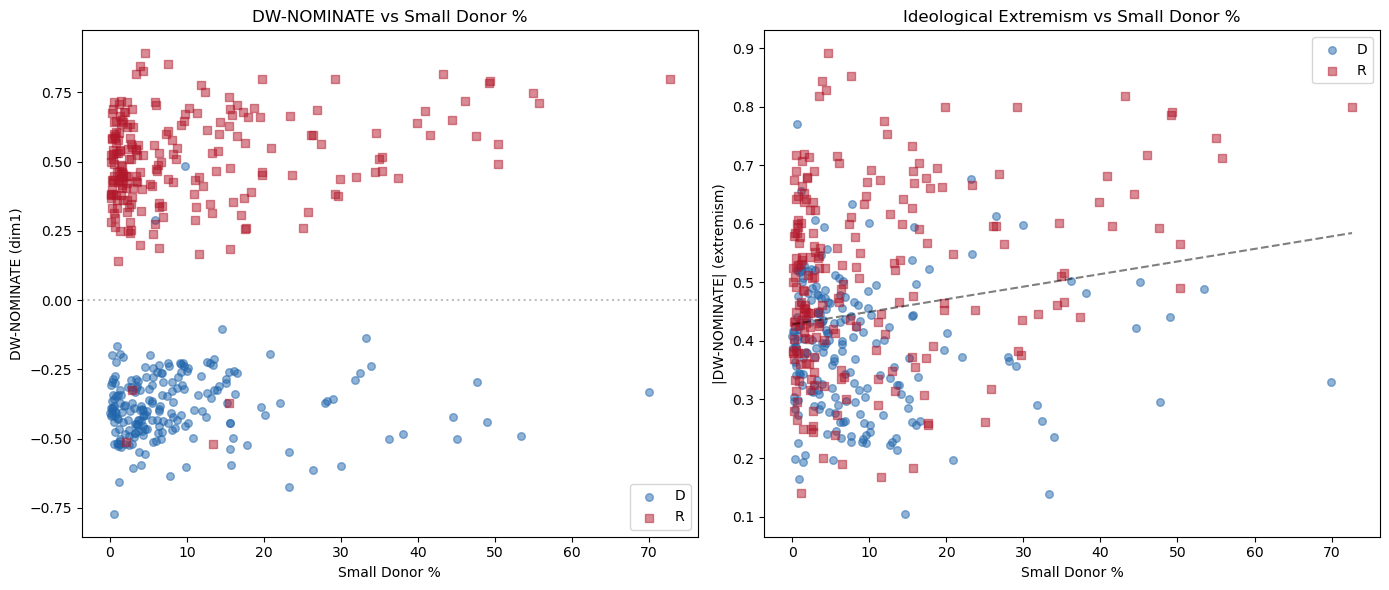

In [47]:

sample.to_csv(OUTPUT_CSV, index=False)
print(f"Saved → {OUTPUT_CSV}  ({len(sample)} rows, {len(sample.columns)} columns)")
print(f"\nNew columns added: nominate_dim1, nominate_dim2, nokken_poole_dim1, nokken_poole_dim2, number_of_votes, congress, nominate_abs")
 
# %% [markdown]
# ## 6 · Quick scatter: DW-NOMINATE vs small donor %
 
# %%
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Left: raw dim1
ax = axes[0]
for party, color, marker in [("D", "#2166ac", "o"), ("R", "#b2182b", "s")]:
    mask = sample["party_code"] == party
    ax.scatter(sample.loc[mask, "pct_small_donors"], sample.loc[mask, "nominate_dim1"],
               c=color, marker=marker, alpha=0.5, s=30, label=party)
ax.set_xlabel("Small Donor %")
ax.set_ylabel("DW-NOMINATE (dim1)")
ax.set_title("DW-NOMINATE vs Small Donor %")
ax.legend()
ax.axhline(0, color="grey", linestyle=":", alpha=0.5)
 
# Right: absolute dim1 (extremism)
ax = axes[1]
for party, color, marker in [("D", "#2166ac", "o"), ("R", "#b2182b", "s")]:
    mask = sample["party_code"] == party
    ax.scatter(sample.loc[mask, "pct_small_donors"], sample.loc[mask, "nominate_abs"],
               c=color, marker=marker, alpha=0.5, s=30, label=party)
 
valid = sample[["pct_small_donors", "nominate_abs"]].dropna()
z = np.polyfit(valid["pct_small_donors"], valid["nominate_abs"], 1)
x_line = np.linspace(valid["pct_small_donors"].min(), valid["pct_small_donors"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "k--", alpha=0.5)
 
ax.set_xlabel("Small Donor %")
ax.set_ylabel("|DW-NOMINATE| (extremism)")
ax.set_title("Ideological Extremism vs Small Donor %")
ax.legend()
 
plt.tight_layout()
plt.savefig("dw_nominate_vs_small_donors.png", dpi=150, bbox_inches="tight")
plt.show()

In [48]:
import statsmodels.formula.api as smf

sample["nominate_abs"] = sample["nominate_dim1"].abs()

for party, label in [("D", "Democrats"), ("R", "Republicans")]:
    sub = sample[sample["party_code"] == party].dropna(subset=["nominate_dim1", "pct_small_donors"])
    
    r_raw = sub["pct_small_donors"].corr(sub["nominate_dim1"])
    r_abs = sub["pct_small_donors"].corr(sub["nominate_abs"])
    
    m1 = smf.ols("nominate_dim1 ~ pct_small_donors", data=sub).fit()
    m2 = smf.ols("nominate_abs ~ pct_small_donors", data=sub).fit()
    
    print(f"=== {label} (n={len(sub)}) ===")
    print(f"  pct_small_donors vs dim1:      r = {r_raw:+.3f}")
    print(f"  pct_small_donors vs |dim1|:    r = {r_abs:+.3f}")
    print(f"  OLS dim1 ~ donors:   β = {m1.params['pct_small_donors']:+.5f}, p = {m1.pvalues['pct_small_donors']:.4f}, R² = {m1.rsquared:.3f}")
    print(f"  OLS |dim1| ~ donors: β = {m2.params['pct_small_donors']:+.5f}, p = {m2.pvalues['pct_small_donors']:.4f}, R² = {m2.rsquared:.3f}")
    print()

=== Democrats (n=206) ===
  pct_small_donors vs dim1:      r = +0.027
  pct_small_donors vs |dim1|:    r = -0.036
  OLS dim1 ~ donors:   β = +0.00034, p = 0.6997, R² = 0.001
  OLS |dim1| ~ donors: β = -0.00037, p = 0.6027, R² = 0.001

=== Republicans (n=216) ===
  pct_small_donors vs dim1:      r = +0.223
  pct_small_donors vs |dim1|:    r = +0.272
  OLS dim1 ~ donors:   β = +0.00330, p = 0.0010, R² = 0.050
  OLS |dim1| ~ donors: β = +0.00310, p = 0.0001, R² = 0.074



In [49]:
user = pd.read_csv("../coding_sentiment/house/user_partisanship_summary.csv")
bridge = sample[["twitter", "nominate_dim1", "nominate_abs"]].dropna(subset=["nominate_dim1"]).copy()
bridge["handle_lower"] = bridge["twitter"].str.lower().str.strip()

user_nom = user.merge(bridge[["handle_lower", "nominate_dim1", "nominate_abs"]], on="handle_lower", how="inner")

print(f"Members with both scores: {len(user_nom)}")
print(f"  partisanship_score vs nominate_dim1:   r = {user_nom['partisanship_score'].corr(user_nom['nominate_dim1']):+.3f}")
print(f"  partisanship_score vs |nominate_dim1|: r = {user_nom['partisanship_score'].corr(user_nom['nominate_abs']):+.3f}")
print(f"  outrage_index vs |nominate_dim1|:      r = {user_nom['outrage_index'].corr(user_nom['nominate_abs']):+.3f}")
print(f"  avg_anger vs |nominate_dim1|:          r = {user_nom['avg_anger'].corr(user_nom['nominate_abs']):+.3f}")
print(f"  pct_negative vs |nominate_dim1|:       r = {user_nom['pct_negative'].corr(user_nom['nominate_abs']):+.3f}")

Members with both scores: 414
  partisanship_score vs nominate_dim1:   r = +0.428
  partisanship_score vs |nominate_dim1|: r = +0.525
  outrage_index vs |nominate_dim1|:      r = +0.557
  avg_anger vs |nominate_dim1|:          r = +0.539
  pct_negative vs |nominate_dim1|:       r = +0.567


In [50]:
bridge = sample[["twitter", "nominate_dim1", "nominate_abs", "party_code"]].dropna(subset=["nominate_dim1"]).copy()
bridge["handle_lower"] = bridge["twitter"].str.lower().str.strip()

user_nom = user.merge(bridge[["handle_lower", "nominate_dim1", "nominate_abs", "party_code"]],
                       on="handle_lower", how="inner", suffixes=("", "_sample"))

# Use party_code from user if it exists, otherwise from sample
if "party_code_sample" in user_nom.columns:
    user_nom["party_code"] = user_nom["party_code"].fillna(user_nom["party_code_sample"])

for party, label in [("D", "Democrats"), ("R", "Republicans")]:
    sub = user_nom[user_nom["party_code"] == party]
    print(f"=== {label} (n={len(sub)}) ===")
    for metric in ["partisanship_score", "outrage_index", "pct_negative", "avg_anger"]:
        r1 = sub[metric].corr(sub["nominate_dim1"])
        r2 = sub[metric].corr(sub["nominate_abs"])
        print(f"  {metric:25s}  vs dim1: r={r1:+.3f}   vs |dim1|: r={r2:+.3f}")
    print()

=== Democrats (n=205) ===
  partisanship_score         vs dim1: r=-0.073   vs |dim1|: r=+0.245
  outrage_index              vs dim1: r=-0.084   vs |dim1|: r=+0.242
  pct_negative               vs dim1: r=-0.049   vs |dim1|: r=+0.227
  avg_anger                  vs dim1: r=-0.152   vs |dim1|: r=+0.296

=== Republicans (n=209) ===
  partisanship_score         vs dim1: r=+0.550   vs |dim1|: r=+0.571
  outrage_index              vs dim1: r=+0.568   vs |dim1|: r=+0.609
  pct_negative               vs dim1: r=+0.574   vs |dim1|: r=+0.606
  avg_anger                  vs dim1: r=+0.524   vs |dim1|: r=+0.573



### adding MIT election lab outcome data

## Add Election Competitiveness to sample_house_full
#
# Downloads U.S. House election returns from MIT Election Data & Science Lab,
# computes margin of victory for the 2024 election, and merges onto
# `sample_house_full.csv`.
#
# We compute two metrics:
# - **margin_of_victory** — winner's vote share minus runner-up's share (0–100)
# - **competitive** — binary flag for margin < 10 points (swing district)
#
# **Source:** MIT Election Data and Science Lab, 2017, "U.S. House 1976–2024",
# https://doi.org/10.7910/DVN/IG0UN2, Harvard Dataverse

In [51]:

# MIT Election Lab House returns — this is a large file (~30 MB)
# Download manually if the URL doesn't work:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/IG0UN2
HOUSE_RETURNS_CSV = "../main/1976-2024-house.tab"  # local path after download
 
# Election year to use for margin of victory
ELECTION_YEAR = 2024
 

In [52]:
house = pd.read_csv(HOUSE_RETURNS_CSV)
print(f"Total rows: {len(house):,}")
print(f"Years: {sorted(house['year'].unique())[-5:]}")
print(f"Columns: {house.columns.tolist()}")
 
# Filter to target election year, general election only
h24 = house[
    (house["year"] == ELECTION_YEAR) &
    (house["stage"] == "GEN")
].copy()
print(f"\n{ELECTION_YEAR} general election rows: {len(h24)}")
h24.head()
 

Total rows: 33,805
Years: [2016, 2018, 2020, 2022, 2024]
Columns: ['year', 'state', 'state_po', 'state_fips', 'state_cen', 'state_ic', 'office', 'district', 'stage', 'runoff', 'special', 'candidate', 'party', 'writein', 'mode', 'candidatevotes', 'totalvotes', 'unofficial', 'version', 'fusion_ticket']

2024 general election rows: 1353


/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_93239/1560374189.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  house = pd.read_csv(HOUSE_RETURNS_CSV)


,year,state,state_po,state_fips,state_cen,state_ic,office,district,stage,runoff,special,candidate,party,writein,mode,candidatevotes,totalvotes,unofficial,version,fusion_ticket
32452,2024,ALABAMA,AL,1,63,41,US HOUSE,1,GEN,False,False,BARRY MOORE,REPUBLICAN,False,TOTAL,258619,329854,False,20250910,False
32453,2024,ALABAMA,AL,1,63,41,US HOUSE,1,GEN,False,False,TOM HOLMES,DEMOCRAT,False,TOTAL,70929,329854,False,20250910,False
32454,2024,ALABAMA,AL,1,63,41,US HOUSE,1,GEN,False,False,WRITEIN,NaN,True,TOTAL,306,329854,False,20250910,False
32455,2024,ALABAMA,AL,1,63,41,US HOUSE,2,GEN,False,False,CAROLEENE DOBSON,REPUBLICAN,False,TOTAL,131414,289674,False,20250910,False
32456,2024,ALABAMA,AL,1,63,41,US HOUSE,2,GEN,False,False,SHOMARI FIGURES,DEMOCRAT,False,TOTAL,158041,289674,False,20250910,False


In [53]:
# Compute total votes per district
district_totals = (
    h24.groupby(["state_po", "district"])["candidatevotes"]
    .sum()
    .reset_index()
    .rename(columns={"candidatevotes": "total_votes"})
)
 
# Merge totals back
h24 = h24.merge(district_totals, on=["state_po", "district"])
h24["vote_share"] = h24["candidatevotes"] / h24["total_votes"] * 100
 
# For each district, find the top two vote-getters
margins = []
for (state, dist), grp in h24.groupby(["state_po", "district"]):
    top2 = grp.nlargest(2, "candidatevotes")
    winner = top2.iloc[0]
    runner_up_share = top2.iloc[1]["vote_share"] if len(top2) > 1 else 0
 
    margins.append({
        "state": state,
        "district": int(dist) if dist != 0 else 0,
        "winner_name": winner["candidate"],
        "winner_party": winner["party"],
        "winner_share": winner["vote_share"],
        "runner_up_share": runner_up_share,
        "margin_of_victory": winner["vote_share"] - runner_up_share,
        "total_votes": winner["total_votes"],
    })
 
margins_df = pd.DataFrame(margins)
margins_df["competitive"] = (margins_df["margin_of_victory"] < 10).astype(int)
 
print(f"Districts: {len(margins_df)}")
print(f"\nMargin of victory distribution:")
print(margins_df["margin_of_victory"].describe().round(1))
print(f"\nCompetitive (margin < 10pt): {margins_df['competitive'].sum()} / {len(margins_df)}")
 

Districts: 436

Margin of victory distribution:
count    436.0
mean      29.9
std       21.1
min        0.1
25%       14.7
50%       27.0
75%       39.6
max      100.0
Name: margin_of_victory, dtype: float64

Competitive (margin < 10pt): 70 / 436


In [54]:
sample = pd.read_csv(SAMPLE_CSV)
print(f"Sample rows: {len(sample)}")
 
# We need state abbreviation and district number to join.
# If you have district info from VoteView (state_abbrev, district_code), use those.
# Otherwise we'll use the state column from sample_house_full.
 
# Check what district info we have
if "district_code" in sample.columns:
    print("Using district_code from VoteView merge")
    sample["join_state"] = sample["state_abbrev"]
    sample["join_district"] = sample["district_code"]
elif "state" in sample.columns:
    # state is the 2-letter abbreviation from the legislators JSON
    print("Using state from legislators JSON — need to add district numbers")
    sample["join_state"] = sample["state"]
    # District info isn't in sample_house_full yet — we'll need to join via bioguide
    print("⚠️  No district number in sample. Will try name matching instead.")
 

Sample rows: 425
Using state from legislators JSON — need to add district numbers
⚠️  No district number in sample. Will try name matching instead.


In [55]:
VOTEVIEW_URL = "https://voteview.com/static/data/out/members/HSall_members.csv"
 
try:
    vv = pd.read_csv(VOTEVIEW_URL)
except:
    vv = pd.read_csv("HSall_members.csv")  # local fallback
 
vv118 = vv[(vv["congress"] == 118) & (vv["chamber"] == "House")].copy()
vv_districts = vv118[["bioguide_id", "state_abbrev", "district_code"]].rename(
    columns={"bioguide_id": "bioguide"}
)
 
# Merge district info onto sample
sample = sample.merge(vv_districts, on="bioguide", how="left", suffixes=("", "_vv"))
 
# Handle potential duplicate columns
if "state_abbrev_vv" in sample.columns:
    sample["state_abbrev"] = sample["state_abbrev"].fillna(sample["state_abbrev_vv"])
    sample["district_code"] = sample["district_code"].fillna(sample["district_code_vv"])
    sample = sample.drop(columns=[c for c in sample.columns if c.endswith("_vv")])
 
print(f"District info coverage: {sample['district_code'].notna().sum()} / {len(sample)}")
 

District info coverage: 422 / 425


In [56]:
sample["join_state"] = sample["state_abbrev"]
sample["join_district"] = sample["district_code"].fillna(0).astype(int)
 
margins_df["join_state"] = margins_df["state"]
margins_df["join_district"] = margins_df["district"].astype(int)
 
# At-large districts: MIT data uses 0 or 1 for at-large, VoteView uses 0 or 1
# Normalize: treat district 0 as at-large
margins_df.loc[margins_df["join_district"] == 0, "join_district"] = 1  # some states use 1
 
merge_cols = ["join_state", "join_district"]
result_cols = ["margin_of_victory", "competitive", "winner_share", "total_votes"]
 
sample = sample.merge(
    margins_df[merge_cols + result_cols],
    on=merge_cols,
    how="left",
    suffixes=("", "_elec")
)
 
matched = sample["margin_of_victory"].notna().sum()
print(f"Matched: {matched} / {len(sample)}")
 
if sample["margin_of_victory"].isna().any():
    unmatched = sample[sample["margin_of_victory"].isna()]
    print(f"\nUnmatched ({len(unmatched)}):")
    print(unmatched[["official_full", "state", "join_state", "join_district"]].to_string())
 
# %% [markdown]
# ## 5 · Quick analysis
 
# %%
print("Margin of victory distribution (matched members):")
matched_sample = sample[sample["margin_of_victory"].notna()]
print(matched_sample["margin_of_victory"].describe().round(1))
 
print(f"\nCorrelations:")
print(f"  pct_small_donors vs margin_of_victory: r = {matched_sample['pct_small_donors'].corr(matched_sample['margin_of_victory']):+.3f}")
 
if "nominate_abs" in sample.columns:
    print(f"  |DW-NOMINATE| vs margin_of_victory:   r = {matched_sample['nominate_abs'].corr(matched_sample['margin_of_victory']):+.3f}")
 
# By party
for party in ["D", "R"]:
    sub = matched_sample[matched_sample["party_code"] == party]
    r = sub["pct_small_donors"].corr(sub["margin_of_victory"])
    print(f"  [{party}] pct_small_donors vs margin: r = {r:+.3f}")
 

Matched: 419 / 425

Unmatched (6):
             official_full state join_state  join_district
30             Wesley Bell    MO        NaN              0
91        Craig A. Goldman    TX        NaN              0
116      Alan S. Lowenthal    CA        NaN              0
232     Stacey E. Plaskett    VI         VI              0
291  Eleanor Holmes Norton    DC         DC              0
318        James C. Moylan    GU         GU              0
Margin of victory distribution (matched members):
count    419.0
mean      30.2
std       21.1
min        0.2
25%       15.3
50%       27.2
75%       39.6
max      100.0
Name: margin_of_victory, dtype: float64

Correlations:
  pct_small_donors vs margin_of_victory: r = -0.023
  [D] pct_small_donors vs margin: r = -0.002
  [R] pct_small_donors vs margin: r = -0.046


In [57]:

# Clean up join columns
sample = sample.drop(columns=["join_state", "join_district"], errors="ignore")
 
sample.to_csv(OUTPUT_CSV, index=False)
print(f"Saved → {OUTPUT_CSV}  ({len(sample)} rows, {len(sample.columns)} columns)")
print(f"\nNew columns: margin_of_victory, competitive, winner_share, total_votes")

Saved → ../main/house_with_features.csv  (425 rows, 29 columns)

New columns: margin_of_victory, competitive, winner_share, total_votes


In [58]:
bridge = sample[["twitter", "margin_of_victory", "competitive"]].dropna(subset=["margin_of_victory"]).copy()
bridge["handle_lower"] = bridge["twitter"].str.lower().str.strip()

user_margin = user.merge(bridge[["handle_lower", "margin_of_victory", "competitive"]], on="handle_lower", how="inner")

print(f"Members with both scores: {len(user_margin)}")
print(f"\nCorrelations with margin_of_victory:")
for metric in ["partisanship_score", "outrage_index", "pct_negative", "avg_sentiment"]:
    r = user_margin[metric].corr(user_margin["margin_of_victory"])
    print(f"  {metric:25s}  r = {r:+.3f}")

print(f"\nCompetitive vs safe seat mean partisanship:")
for comp, label in [(1, "Competitive (<10pt)"), (0, "Safe (>=10pt)")]:
    sub = user_margin[user_margin["competitive"] == comp]
    print(f"  {label:25s}  n={len(sub):3d}  partisanship={sub['partisanship_score'].mean():+.3f}  outrage={sub['outrage_index'].mean():.4f}")

Members with both scores: 411

Correlations with margin_of_victory:
  partisanship_score         r = +0.179
  outrage_index              r = +0.187
  pct_negative               r = +0.153
  avg_sentiment              r = -0.166

Competitive vs safe seat mean partisanship:
  Competitive (<10pt)        n= 64  partisanship=-0.470  outrage=0.1120
  Safe (>=10pt)              n=347  partisanship=+0.084  outrage=0.1572


In [59]:
user_full = user_margin.copy()
user_full["is_R"] = (user_full["party_code"] == "R").astype(int)
user_full["log_tweet_count"] = np.log1p(user_full["tweet_count"])

# Model with margin added
m_margin = smf.ols(
    "partisanship_score ~ pct_small_donors + is_R + log_tweet_count + margin_of_victory",
    data=user_full
).fit()

print("MODEL: partisanship ~ small_donors + party + tweet_volume + margin")
print(f"  R² = {m_margin.rsquared:.3f}")
for param in ["pct_small_donors", "is_R", "log_tweet_count", "margin_of_victory"]:
    beta = m_margin.params[param]
    p = m_margin.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

print(m_margin.summary())

MODEL: partisanship ~ small_donors + party + tweet_volume + margin
  R² = 0.271
  pct_small_donors           β = +0.0164  p = 0.0000  ***
  is_R                       β = +0.6086  p = 0.0000  ***
  log_tweet_count            β = +0.2466  p = 0.0000  ***
  margin_of_victory          β = +0.0076  p = 0.0000  ***
                            OLS Regression Results                            
Dep. Variable:     partisanship_score   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     37.66
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           8.45e-27
Time:                        18:07:09   Log-Likelihood:                -457.27
No. Observations:                 411   AIC:                             924.5
Df Residuals:                     406   BIC:                             944.6
Df Model:                           4                   

## approaching small donor as outcome

In [60]:
tweets = pd.read_csv("/Users/anngo/Documents/GitHub/26-spring-ngo-a/data/coding_sentiment/house/house_tweets_enriched.csv", low_memory=False)
tweets["handle_lower"] = tweets["Account"].str.lower().str.strip()

In [61]:
# ── Small Donor % as Outcome Variable ─────────────────────────────────────

# Build the analysis dataframe
user_full = user_margin.copy()
user_full["is_R"] = (user_full["party_code"] == "R").astype(int)
user_full["log_tweet_count"] = np.log1p(user_full["tweet_count"])
user_full["log_avg_retweets"] = np.log1p(user_full.get("avg_retweets", 0))

# If avg_retweets isn't in user_margin, pull from tweets
if "avg_retweets" not in user_full.columns:
    tweet_eng = tweets.groupby("handle_lower").agg(
        avg_retweets=("Retweets", "mean"),
        avg_likes=("Likes", "mean"),
    ).reset_index()
    user_full = user_full.merge(tweet_eng, on="handle_lower", how="left", suffixes=("", "_dup"))
    user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]
    user_full["log_avg_retweets"] = np.log1p(user_full["avg_retweets"])
    user_full["log_avg_likes"] = np.log1p(user_full["avg_likes"])

print(f"Analysis n = {len(user_full)}")
print(f"Columns available: {sorted(user_full.columns.tolist())}")

Analysis n = 411
Columns available: ['avg_anger', 'avg_disgust', 'avg_fear', 'avg_joy', 'avg_likes', 'avg_retweets', 'avg_sadness', 'avg_sentiment', 'competitive', 'handle_lower', 'is_R', 'log_avg_likes', 'log_avg_retweets', 'log_tweet_count', 'margin_of_victory', 'official_full', 'outrage_index', 'partisanship_score', 'party_code', 'pct_extreme', 'pct_negative', 'pct_positive', 'pct_small_donors', 'quartile', 'sentiment_std', 'tweet_count', 'z_avg_anger', 'z_avg_disgust', 'z_pct_negative', 'z_sentiment_std']


In [62]:
# ── Sequential models: what predicts small-donor funding? ─────────────────

# M1: just party
m1 = smf.ols("pct_small_donors ~ is_R", data=user_full).fit()

# M2: party + electoral context
m2 = smf.ols("pct_small_donors ~ is_R + margin_of_victory", data=user_full).fit()

# M3: + twitter behavior
m3 = smf.ols("pct_small_donors ~ is_R + margin_of_victory + log_tweet_count", data=user_full).fit()

# M4: + engagement
m4 = smf.ols("pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets",
             data=user_full).fit()

# M5: + sentiment
m5 = smf.ols("pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + avg_sentiment",
             data=user_full).fit()

# M6: + emotion (outrage)
m6 = smf.ols("pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + avg_sentiment + outrage_index",
             data=user_full).fit()

# M7: full model with individual emotions instead of composite
m7 = smf.ols("pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + avg_sentiment + avg_anger + avg_disgust + avg_fear + avg_joy",
             data=user_full).fit()

models = [
    ("M1: party only",           m1),
    ("M2: + margin",             m2),
    ("M3: + tweet volume",       m3),
    ("M4: + retweets",           m4),
    ("M5: + sentiment",          m5),
    ("M6: + outrage index",      m6),
    ("M7: + individual emotions", m7),
]

print(f"{'Model':<30s}  {'R²':>6s}  {'Adj R²':>6s}  {'AIC':>8s}")
print("-" * 56)
for name, m in models:
    print(f"{name:<30s}  {m.rsquared:6.3f}  {m.rsquared_adj:6.3f}  {m.aic:8.1f}")

Model                               R²  Adj R²       AIC
--------------------------------------------------------
M1: party only                   0.005   0.003    3238.7
M2: + margin                     0.006   0.001    3240.3
M3: + tweet volume               0.009   0.002    3240.9
M4: + retweets                   0.315   0.308    3091.5
M5: + sentiment                  0.320   0.311    3090.3
M6: + outrage index              0.321   0.310    3091.9
M7: + individual emotions        0.333   0.318    3090.3


In [63]:
# ── Full model details ────────────────────────────────────────────────────

print("=" * 70)
print("M6: pct_small_donors ~ party + margin + tweets + retweets + sentiment + outrage")
print("=" * 70)
for param in m6.params.index:
    beta = m6.params[param]
    p = m6.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

print()
print(m6.summary())

M6: pct_small_donors ~ party + margin + tweets + retweets + sentiment + outrage
  Intercept                  β = -2.2693  p = 0.7042  
  is_R                       β = +2.1786  p = 0.0661  
  margin_of_victory          β = -0.0460  p = 0.0629  
  log_tweet_count            β = -0.1004  p = 0.8712  
  log_avg_retweets           β = +5.4027  p = 0.0000  ***
  avg_sentiment              β = +2.4846  p = 0.6448  
  outrage_index              β = -12.2218  p = 0.5375  

                            OLS Regression Results                            
Dep. Variable:       pct_small_donors   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     31.76
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.74e-31
Time:                        18:07:19   Log-Likelihood:                -1539.0
No. Observations:                 411   AIC:            

In [64]:
# ── M7 details: which emotions matter? ────────────────────────────────────

print("=" * 70)
print("M7: with individual emotions")
print("=" * 70)
for param in m7.params.index:
    beta = m7.params[param]
    p = m7.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

M7: with individual emotions
  Intercept                  β = +0.2274  p = 0.9711  
  is_R                       β = +2.6777  p = 0.0342  *
  margin_of_victory          β = -0.0365  p = 0.1424  
  log_tweet_count            β = +0.2938  p = 0.6441  
  log_avg_retweets           β = +5.3007  p = 0.0000  ***
  avg_sentiment              β = +16.4651  p = 0.0726  
  avg_anger                  β = -8.1268  p = 0.7399  
  avg_disgust                β = +18.3257  p = 0.6437  
  avg_fear                   β = -17.2264  p = 0.1082  
  avg_joy                    β = -23.2214  p = 0.0639  


In [65]:
# ── Standardized coefficients for effect size comparison ──────────────────
from scipy.stats import zscore

std_vars = ["pct_small_donors", "is_R", "margin_of_victory", "log_tweet_count",
            "log_avg_retweets", "avg_sentiment", "outrage_index"]

user_std = user_full[std_vars].dropna().apply(zscore)

m_std = smf.ols(
    "pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + avg_sentiment + outrage_index",
    data=user_std
).fit()

print("Standardized coefficients (all variables z-scored):")
print("Effect sizes are directly comparable across predictors.\n")
for param in m_std.params.index:
    if param == "Intercept":
        continue
    beta = m_std.params[param]
    p = m_std.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    bar = "█" * int(abs(beta) * 30)
    direction = "+" if beta > 0 else "-"
    print(f"  {param:25s}  β = {beta:+.3f}  {bar} {sig}")

Standardized coefficients (all variables z-scored):
Effect sizes are directly comparable across predictors.

  is_R                       β = +0.088  ██ 
  margin_of_victory          β = -0.079  ██ 
  log_tweet_count            β = -0.007   
  log_avg_retweets           β = +0.632  ██████████████████ ***
  avg_sentiment              β = +0.050  █ 
  outrage_index              β = -0.069  ██ 


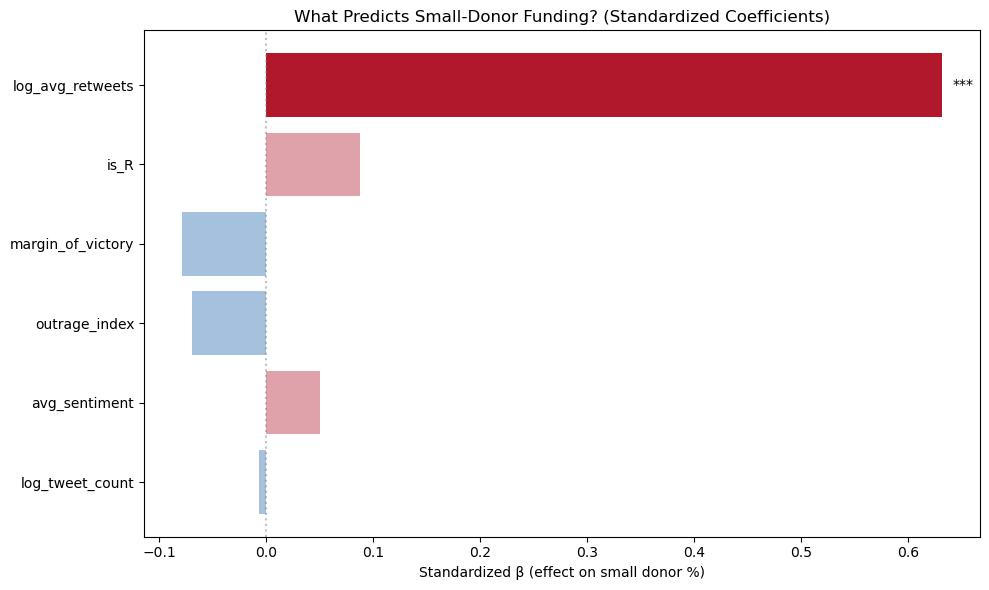

In [66]:
# ── Visualization: standardized effect sizes ──────────────────────────────

params_to_plot = [p for p in m_std.params.index if p != "Intercept"]
betas = [m_std.params[p] for p in params_to_plot]
pvals = [m_std.pvalues[p] for p in params_to_plot]

# Sort by absolute effect size
order = np.argsort(np.abs(betas))
params_sorted = [params_to_plot[i] for i in order]
betas_sorted = [betas[i] for i in order]
pvals_sorted = [pvals[i] for i in order]

colors = ["#b2182b" if b > 0 else "#2166ac" for b in betas_sorted]
alphas = [1.0 if p < 0.05 else 0.4 for p in pvals_sorted]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(params_sorted, betas_sorted, color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

ax.axvline(0, color="grey", linestyle=":", alpha=0.5)
ax.set_xlabel("Standardized β (effect on small donor %)")
ax.set_title("What Predicts Small-Donor Funding? (Standardized Coefficients)")

# Add significance stars
for i, (beta, p) in enumerate(zip(betas_sorted, pvals_sorted)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    offset = 0.01 if beta >= 0 else -0.01
    ax.text(beta + offset, i, sig, va="center", fontsize=10,
            ha="left" if beta >= 0 else "right")

plt.tight_layout()
plt.savefig("predictors_of_small_donors.png", dpi=150, bbox_inches="tight")
plt.show()

In [67]:
check_cols = ["log_avg_retweets", "avg_sentiment", "outrage_index", "log_tweet_count", "pct_small_donors"]
print(user_full[check_cols].corr().round(3))

                  log_avg_retweets  avg_sentiment  outrage_index  \
log_avg_retweets             1.000         -0.603          0.648   
avg_sentiment               -0.603          1.000         -0.922   
outrage_index                0.648         -0.922          1.000   
log_tweet_count              0.131         -0.148          0.172   
pct_small_donors             0.552         -0.289          0.309   

                  log_tweet_count  pct_small_donors  
log_avg_retweets            0.131             0.552  
avg_sentiment              -0.148            -0.289  
outrage_index               0.172             0.309  
log_tweet_count             1.000             0.053  
pct_small_donors            0.053             1.000  


In [68]:
# Path a: outrage → retweets
a = smf.ols("log_avg_retweets ~ outrage_index + is_R", data=user_full).fit()
print(f"Path a (outrage → retweets):  β = {a.params['outrage_index']:.3f}, p = {a.pvalues['outrage_index']:.4f}")

# Path b: retweets → small donors (controlling for outrage)  
b = smf.ols("pct_small_donors ~ log_avg_retweets + outrage_index + is_R", data=user_full).fit()
print(f"Path b (retweets → donors):   β = {b.params['log_avg_retweets']:.3f}, p = {b.pvalues['log_avg_retweets']:.4f}")

# Path c: total effect of outrage → small donors
c = smf.ols("pct_small_donors ~ outrage_index + is_R", data=user_full).fit()
print(f"Path c (outrage → donors):    β = {c.params['outrage_index']:.3f}, p = {c.pvalues['outrage_index']:.4f}")

# Path c': direct effect (controlling for retweets)
print(f"Path c' (outrage → donors|RT): β = {b.params['outrage_index']:.3f}, p = {b.pvalues['outrage_index']:.4f}")

# Indirect effect = a * b
indirect = a.params['outrage_index'] * b.params['log_avg_retweets']
total = c.params['outrage_index']
print(f"\nIndirect effect (via retweets): {indirect:.3f}")
print(f"Total effect:                  {total:.3f}")
print(f"Proportion mediated:           {indirect/total:.1%}" if total != 0 else "")

Path a (outrage → retweets):  β = 14.898, p = 0.0000
Path b (retweets → donors):   β = 5.406, p = 0.0000
Path c (outrage → donors):    β = 57.354, p = 0.0000
Path c' (outrage → donors|RT): β = -23.180, p = 0.0281

Indirect effect (via retweets): 80.534
Total effect:                  57.354
Proportion mediated:           140.4%


## adding more features + committees


In [69]:
# ── Add likes (already in tweets) ────────────────────────────────────────
if "log_avg_likes" not in user_full.columns:
    tweet_likes = tweets.groupby("handle_lower").agg(
        avg_likes=("Likes", "mean"),
    ).reset_index()
    user_full = user_full.merge(tweet_likes, on="handle_lower", how="left", suffixes=("", "_dup"))
    user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]
    user_full["log_avg_likes"] = np.log1p(user_full["avg_likes"])

print(f"Likes coverage: {user_full['log_avg_likes'].notna().sum()}")

Likes coverage: 411


In [73]:
sample = pd.read_csv(OUTPUT_CSV)
sample["handle_lower"] = sample["twitter"].str.lower().str.strip()

# Re-add DW-NOMINATE
vv_cols = vv118[["bioguide_id", "nominate_dim1", "nominate_dim2",
                  "nokken_poole_dim1", "nokken_poole_dim2"]].copy()
vv_cols = vv_cols.rename(columns={"bioguide_id": "bioguide"}).drop_duplicates("bioguide")

sample = sample.merge(vv_cols, on="bioguide", how="left")
sample["nominate_abs"] = sample["nominate_dim1"].abs()

sample.to_csv(OUTPUT_CSV, index=False)
print(f"DW-NOMINATE coverage: {sample['nominate_dim1'].notna().sum()} / {len(sample)}")

DW-NOMINATE coverage: 422 / 425


In [72]:
print([c for c in sample.columns if "nomin" in c.lower()])
print(sample.columns.tolist())

[]
['Name', 'Total Raised', 'Total from Small Donors', 'Percent from Small Donors*', 'total money raised', 'party_code', 'party_full', 'Total Raised_num', 'Total from Small Donors_num', 'pct_small_donors', 'clean_name', 'match_score', 'match_method', 'first', 'last', 'official_full', 'party', 'chamber', 'state', 'bioguide', 'twitter', 'quartile', 'sample_method', 'state_abbrev', 'district_code', 'margin_of_victory', 'competitive', 'winner_share', 'total_votes', 'handle_lower']


In [79]:
# ── Add committee assignments ────────────────────────────────────────────
# High-profile committees that generate media attention and fundraising

import json


HIGH_PROFILE_COMMITTEES = {
    "HSAP": "Appropriations",
    "HSWM": "Ways and Means",
    "HSRU": "Rules",
    "HSBU": "Budget",
    "HSJU": "Judiciary",
    "HSGO": "Oversight",
    "HSIG": "Intelligence",
    "HSAS": "Armed Services",
    "HSFA": "Foreign Affairs",
    "HSHA": "Administration",
    "HLIG": "Intelligence (Select)",
}

# Load committee membership from unitedstates/congress repo
# File: committee-membership-current.json
try:
    with open("/Users/anngo/Documents/GitHub/26-spring-ngo-a/data/main/committee-membership-current.json") as f:
        committees = json.load(f)
except FileNotFoundError:
    print("⚠️  committee-membership-current.json not found.")
    print("Download from: https://github.com/unitedstates/congress-legislators")
    print("URL: https://raw.githubusercontent.com/unitedstates/congress-legislators/main/committee-membership-current.json")
    committees = None

if committees:
    # Build bioguide → committee list mapping
    member_committees = {}
    for committee_id, members in committees.items():
        # Strip subcommittee suffixes (e.g., "HSJU03" → "HSJU")
        parent_id = committee_id[:4]
        for member in members:
            bid = member.get("bioguide", "")
            if bid:
                member_committees.setdefault(bid, set()).add(parent_id)

    # Count committees and flag high-profile
    comm_data = []
    for bid, comms in member_committees.items():
        high_profile = comms & set(HIGH_PROFILE_COMMITTEES.keys())
        comm_data.append({
            "bioguide": bid,
            "n_committees": len(comms),
            "n_high_profile": len(high_profile),
            "on_high_profile": 1 if high_profile else 0,
            "committees": ", ".join(sorted(comms)),
        })

    comm_df = pd.DataFrame(comm_data)
    comm_df = comm_df.merge(sample_bio, on="bioguide", how="inner")

    user_full = user_full.merge(
        comm_df[["handle_lower", "n_committees", "n_high_profile", "on_high_profile"]],
        on="handle_lower", how="left", suffixes=("", "_dup")
    )
    user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]
    user_full["on_high_profile"] = user_full["on_high_profile"].fillna(0).astype(int)

    print(f"Committee coverage: {user_full['n_committees'].notna().sum()}")
    print(f"On high-profile committee: {user_full['on_high_profile'].sum()}")

Committee coverage: 441
On high-profile committee: 290


In [82]:
# Add DW-NOMINATE to user_full
bridge = sample[["twitter", "nominate_dim1", "nominate_abs"]].dropna(subset=["nominate_dim1"]).copy()
bridge["handle_lower"] = bridge["twitter"].str.lower().str.strip()

user_full = user_full.merge(
    bridge[["handle_lower", "nominate_dim1", "nominate_abs"]],
    on="handle_lower",
    how="left",
    suffixes=("", "_dup")
)

user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]

print("DW-NOMINATE coverage in user_full:", user_full["nominate_abs"].notna().sum())

DW-NOMINATE coverage in user_full: 615


In [83]:
# ── Updated model sequence ───────────────────────────────────────────────

# Baseline (previous best)
m_base = smf.ols(
    "pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + outrage_index",
    data=user_full).fit()

# + likes
m_likes = smf.ols(
    "pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + log_avg_likes + outrage_index",
    data=user_full).fit()

# + DW-NOMINATE
m_nom = smf.ols(
    "pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + log_avg_likes + outrage_index + nominate_abs",
    data=user_full.dropna(subset=["nominate_abs"])).fit()

# + seniority
m_sen = smf.ols(
    "pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + log_avg_likes + outrage_index + nominate_abs + terms_served",
    data=user_full.dropna(subset=["nominate_abs", "terms_served"])).fit()

# + committees
m_comm = smf.ols(
    "pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + log_avg_likes + outrage_index + nominate_abs + terms_served + on_high_profile",
    data=user_full.dropna(subset=["nominate_abs", "terms_served"])).fit()

# Full kitchen sink
m_full = smf.ols(
    "pct_small_donors ~ is_R + margin_of_victory + log_tweet_count + log_avg_retweets + log_avg_likes + outrage_index + nominate_abs + terms_served + on_high_profile + n_committees",
    data=user_full.dropna(subset=["nominate_abs", "terms_served"])).fit()

models = [
    ("Baseline (prev best)",  m_base),
    ("+ likes",               m_likes),
    ("+ DW-NOMINATE",         m_nom),
    ("+ seniority",           m_sen),
    ("+ high-profile comm",   m_comm),
    ("+ n_committees",        m_full),
]

print(f"{'Model':<25s}  {'R²':>6s}  {'Adj R²':>6s}  {'AIC':>8s}  {'N':>4s}")
print("-" * 60)
for name, m in models:
    print(f"{name:<25s}  {m.rsquared:6.3f}  {m.rsquared_adj:6.3f}  {m.aic:8.1f}  {int(m.nobs):4d}")

Model                          R²  Adj R²       AIC     N
------------------------------------------------------------
Baseline (prev best)        0.296   0.291    4540.0   615
+ likes                     0.297   0.290    4541.8   615
+ DW-NOMINATE               0.314   0.307    4528.0   615
+ seniority                 0.395   0.386    4111.4   573
+ high-profile comm         0.395   0.385    4113.2   573
+ n_committees              0.395   0.384    4053.9   567


In [84]:
# ── Best model coefficients ──────────────────────────────────────────────
best = m_full
print(f"Best model R² = {best.rsquared:.3f}, Adj R² = {best.rsquared_adj:.3f}\n")
for param in best.params.index:
    if param == "Intercept":
        continue
    beta = best.params[param]
    p = best.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

print()
print(best.summary())

Best model R² = 0.395, Adj R² = 0.384

  is_R                       β = +2.9037  p = 0.0010  ***
  margin_of_victory          β = -0.0155  p = 0.4645  
  log_tweet_count            β = +0.7110  p = 0.2237  
  log_avg_retweets           β = +3.8496  p = 0.0261  *
  log_avg_likes              β = +1.5187  p = 0.3517  
  outrage_index              β = -46.3153  p = 0.0000  ***
  nominate_abs               β = +11.1766  p = 0.0024  **
  terms_served               β = -0.7954  p = 0.0000  ***
  on_high_profile            β = -0.7248  p = 0.4469  
  n_committees               β = +0.6280  p = 0.1972  

                            OLS Regression Results                            
Dep. Variable:       pct_small_donors   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     36.27
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           1.51e-54
T

In [85]:
user_full["outrage_index"].describe()

count    615.000000
mean       0.139052
std        0.066732
min        0.001475
25%        0.084197
50%        0.120786
75%        0.188868
max        0.374539
Name: outrage_index, dtype: float64

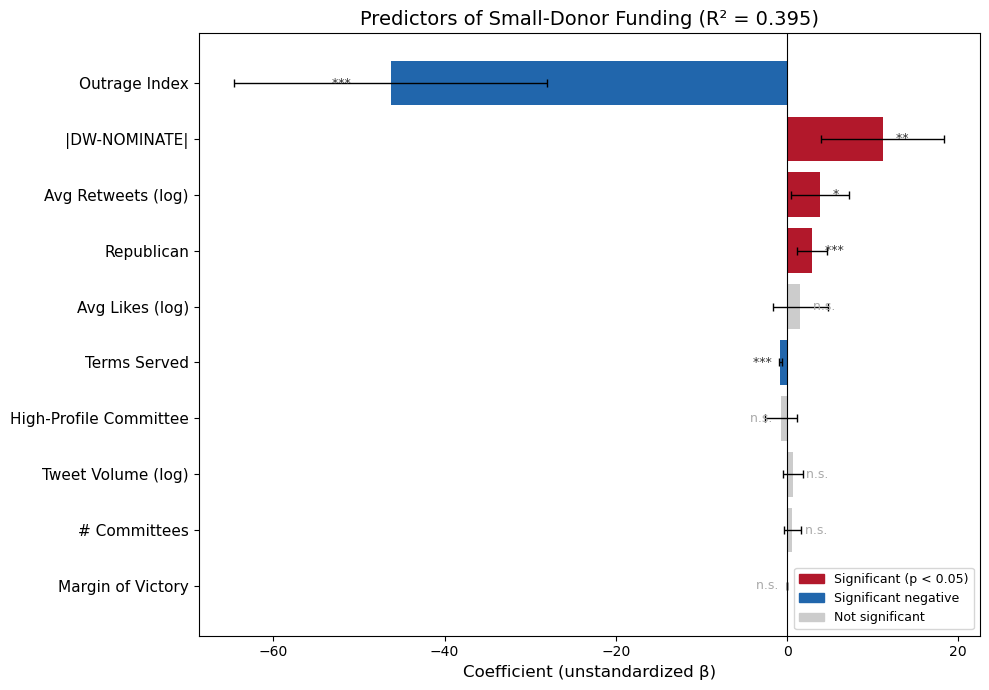

In [86]:
# ── Coefficient plot: all features, significance highlighted ──────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Use the full model
model = m_full  # or m_parsimonious if you ran that

params = [p for p in model.params.index if p != "Intercept"]
betas = [model.params[p] for p in params]
pvals = [model.pvalues[p] for p in params]
conf_low = [model.conf_int().loc[p, 0] for p in params]
conf_high = [model.conf_int().loc[p, 1] for p in params]

# Sort by absolute beta
order = np.argsort(np.abs(betas))
params_sorted = [params[i] for i in order]
betas_sorted = [betas[i] for i in order]
pvals_sorted = [pvals[i] for i in order]
ci_low_sorted = [conf_low[i] for i in order]
ci_high_sorted = [conf_high[i] for i in order]

# Colors: significant = bold, not significant = faded
colors = []
for b, p in zip(betas_sorted, pvals_sorted):
    if p >= 0.05:
        colors.append("#cccccc")
    elif b > 0:
        colors.append("#b2182b")
    else:
        colors.append("#2166ac")

# Errors for confidence intervals
xerr_low = [b - lo for b, lo in zip(betas_sorted, ci_low_sorted)]
xerr_high = [hi - b for b, hi in zip(betas_sorted, ci_high_sorted)]

# Clean up label names
label_map = {
    "is_R": "Republican",
    "margin_of_victory": "Margin of Victory",
    "log_tweet_count": "Tweet Volume (log)",
    "log_avg_retweets": "Avg Retweets (log)",
    "log_avg_likes": "Avg Likes (log)",
    "outrage_index": "Outrage Index",
    "nominate_abs": "|DW-NOMINATE|",
    "terms_served": "Terms Served",
    "on_high_profile": "High-Profile Committee",
    "n_committees": "# Committees",
    "avg_sentiment": "Avg Sentiment",
}
labels = [label_map.get(p, p) for p in params_sorted]

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(params_sorted))

ax.barh(y_pos, betas_sorted, xerr=[xerr_low, xerr_high],
        color=colors, edgecolor="none", capsize=3, error_kw={"linewidth": 1, "color": "#666666"})

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (unstandardized β)", fontsize=12)
ax.set_title(f"Predictors of Small-Donor Funding (R² = {model.rsquared:.3f})", fontsize=14)

# Add significance stars
for i, (beta, p) in enumerate(zip(betas_sorted, pvals_sorted)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    offset = max(abs(beta) * 0.1, 1)
    ha = "left" if beta >= 0 else "right"
    x_pos = beta + offset if beta >= 0 else beta - offset
    ax.text(x_pos, i, f" {sig}", va="center", ha=ha, fontsize=9,
            color="#333333" if p < 0.05 else "#aaaaaa")

# Legend
sig_patch = mpatches.Patch(color="#b2182b", label="Significant (p < 0.05)")
neg_patch = mpatches.Patch(color="#2166ac", label="Significant negative")
ns_patch = mpatches.Patch(color="#cccccc", label="Not significant")
ax.legend(handles=[sig_patch, neg_patch, ns_patch], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("coefficient_plot.png", dpi=150, bbox_inches="tight")
plt.show()

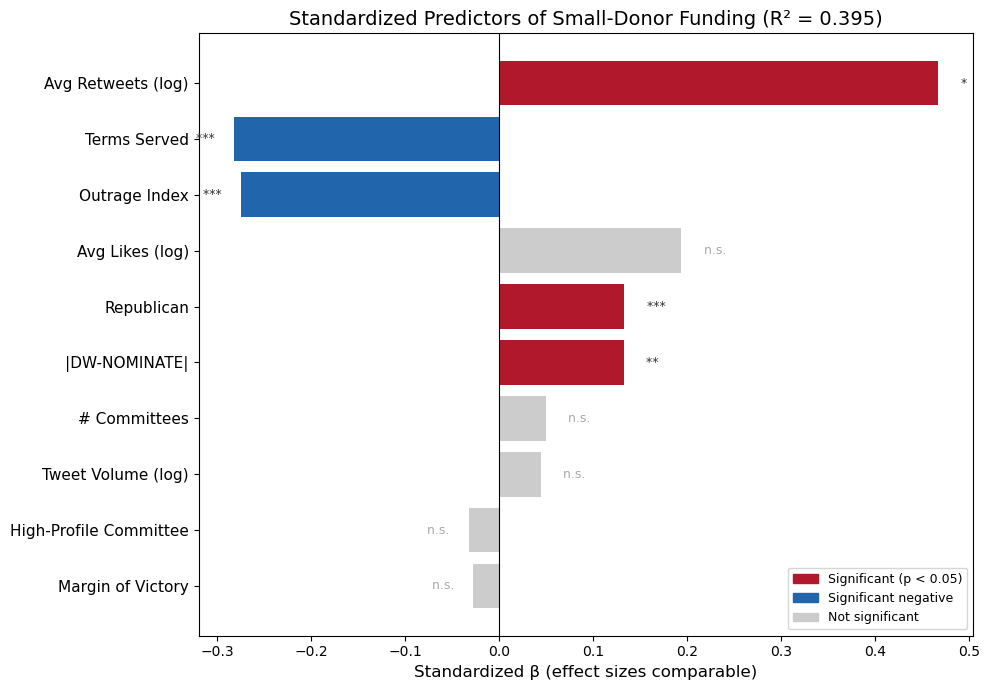

In [88]:
# ── Standardized coefficient plot ─────────────────────────────────────────
from scipy.stats import zscore

model_vars = [p for p in m_full.params.index if p != "Intercept"]
std_data = user_full[["pct_small_donors"] + model_vars].dropna()
std_data = std_data.apply(zscore)

m_std = smf.ols(
    "pct_small_donors ~ " + " + ".join(model_vars),
    data=std_data
).fit()

params_s = [p for p in m_std.params.index if p != "Intercept"]
betas_s = [m_std.params[p] for p in params_s]
pvals_s = [m_std.pvalues[p] for p in params_s]

order_s = np.argsort(np.abs(betas_s))
params_ss = [params_s[i] for i in order_s]
betas_ss = [betas_s[i] for i in order_s]
pvals_ss = [pvals_s[i] for i in order_s]

labels_s = [label_map.get(p, p) for p in params_ss]

colors_s = []
for b, p in zip(betas_ss, pvals_ss):
    if p >= 0.05:
        colors_s.append("#cccccc")
    elif b > 0:
        colors_s.append("#b2182b")
    else:
        colors_s.append("#2166ac")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(params_ss)), betas_ss, color=colors_s, edgecolor="none")
ax.set_yticks(range(len(params_ss)))
ax.set_yticklabels(labels_s, fontsize=11)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized β (effect sizes comparable)", fontsize=12)
ax.set_title(f"Standardized Predictors of Small-Donor Funding (R² = {m_std.rsquared:.3f})", fontsize=14)

for i, (beta, p) in enumerate(zip(betas_ss, pvals_ss)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    offset = 0.02
    ha = "left" if beta >= 0 else "right"
    x_pos = beta + offset if beta >= 0 else beta - offset
    ax.text(x_pos, i, f" {sig}", va="center", ha=ha, fontsize=9,
            color="#333333" if p < 0.05 else "#aaaaaa")

ax.legend(handles=[sig_patch, neg_patch, ns_patch], loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("standardized_coefficient_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [90]:
from scipy.stats import linregress

# Only parse if not already datetime
if tweets["Created At"].dtype == "object":
    tweets["Created At"] = pd.to_datetime(tweets["Created At"], errors="coerce", utc=True)

ref_date = tweets["Created At"].min()
tweets["days_since_start"] = (tweets["Created At"] - ref_date).dt.total_seconds() / 86400

# Vectorized slope calculation instead of .apply()
def calc_slopes(df):
    results = {}
    for handle, grp in df.groupby("handle_lower"):
        g = grp.dropna(subset=["days_since_start", "sentiment_score"])
        if len(g) < 10:
            results[handle] = np.nan
        else:
            slope, _, _, _, _ = linregress(g["days_since_start"].values, g["sentiment_score"].values)
            results[handle] = slope
    return results

slopes = calc_slopes(tweets)
sentiment_trends = pd.DataFrame(list(slopes.items()), columns=["handle_lower", "sentiment_slope"])

user_full = user_full.merge(sentiment_trends, on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]

print(f"Sentiment slope coverage: {user_full['sentiment_slope'].notna().sum()}")
print(f"Negative slope (getting angrier): {(user_full['sentiment_slope'] < 0).sum()}")
print(f"Positive slope (getting nicer):   {(user_full['sentiment_slope'] > 0).sum()}")

Sentiment slope coverage: 612
Negative slope (getting angrier): 182
Positive slope (getting nicer):   430


In [91]:
# ── Emotion diversity (entropy) + dominant emotion ───────────────────────
from scipy.stats import entropy

emotions = ["anger", "fear", "joy", "disgust", "sadness", "surprise", "neutral"]

def emotion_entropy(row):
    scores = [row[e] for e in emotions]
    total = sum(scores)
    if total == 0:
        return np.nan
    probs = [s / total for s in scores]
    return entropy(probs)

tweets["emotion_entropy"] = tweets.apply(emotion_entropy, axis=1)
tweets["dominant_emotion"] = tweets[emotions].idxmax(axis=1)

# Per-member aggregation
emotion_features = tweets.groupby("handle_lower").agg(
    avg_emotion_entropy=("emotion_entropy", "mean"),
    pct_anger_dominant=("dominant_emotion", lambda x: (x == "anger").mean()),
    pct_joy_dominant=("dominant_emotion", lambda x: (x == "joy").mean()),
    pct_disgust_dominant=("dominant_emotion", lambda x: (x == "disgust").mean()),
    pct_fear_dominant=("dominant_emotion", lambda x: (x == "fear").mean()),
    pct_neutral_dominant=("dominant_emotion", lambda x: (x == "neutral").mean()),
).reset_index()

user_full = user_full.merge(emotion_features, on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]

print(f"Emotion entropy coverage: {user_full['avg_emotion_entropy'].notna().sum()}")
print(f"\nDominant emotion distribution (mean across members):")
for col in [c for c in emotion_features.columns if c.startswith("pct_")]:
    print(f"  {col:25s}  {user_full[col].mean():.3f}")

Emotion entropy coverage: 615

Dominant emotion distribution (mean across members):
  pct_anger_dominant         0.089
  pct_joy_dominant           0.362
  pct_disgust_dominant       0.028
  pct_fear_dominant          0.202
  pct_neutral_dominant       0.250


In [92]:
# ── Extreme negative share + neutral share ───────────────────────────────
extreme_features = tweets.groupby("handle_lower").agg(
    pct_extreme_neg=("sentiment_score", lambda x: (x < -0.8).mean()),
    pct_extreme_pos=("sentiment_score", lambda x: (x > 0.8).mean()),
    pct_neutral=("label", lambda x: (x == "neutral").mean()),
).reset_index()

user_full = user_full.merge(extreme_features, on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]

print(f"Coverage: {user_full['pct_extreme_neg'].notna().sum()}")
print(f"\nDistributions:")
for col in ["pct_extreme_neg", "pct_extreme_pos", "pct_neutral"]:
    print(f"  {col:20s}  mean = {user_full[col].mean():.3f}  std = {user_full[col].std():.3f}")

Coverage: 615

Distributions:
  pct_extreme_neg       mean = 0.126  std = 0.088
  pct_extreme_pos       mean = 0.422  std = 0.139
  pct_neutral           mean = 0.240  std = 0.076


In [93]:
# ── Correlations: new features vs pct_small_donors ───────────────────────
new_features = ["sentiment_slope", "avg_emotion_entropy",
                "pct_anger_dominant", "pct_joy_dominant", "pct_disgust_dominant",
                "pct_neutral_dominant", "pct_extreme_neg", "pct_extreme_pos", "pct_neutral"]

print("Correlations with pct_small_donors:")
print("-" * 55)
for f in new_features:
    r = user_full["pct_small_donors"].corr(user_full[f])
    print(f"  {f:25s}  r = {r:+.3f}")

Correlations with pct_small_donors:
-------------------------------------------------------
  sentiment_slope            r = +0.076
  avg_emotion_entropy        r = +0.221
  pct_anger_dominant         r = +0.244
  pct_joy_dominant           r = -0.250
  pct_disgust_dominant       r = +0.271
  pct_neutral_dominant       r = +0.169
  pct_extreme_neg            r = +0.250
  pct_extreme_pos            r = -0.245
  pct_neutral                r = +0.077


In [94]:
# ── Updated model: add the best new features ─────────────────────────────

# Start with previous best, add new features one at a time
m_prev = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + nominate_abs + terms_served",
    data=user_full.dropna(subset=["nominate_abs", "terms_served"])
).fit()

m_slope = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + nominate_abs + terms_served + sentiment_slope",
    data=user_full.dropna(subset=["nominate_abs", "terms_served", "sentiment_slope"])
).fit()

m_entropy = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + nominate_abs + terms_served + sentiment_slope + avg_emotion_entropy",
    data=user_full.dropna(subset=["nominate_abs", "terms_served", "sentiment_slope"])
).fit()

m_dominant = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + nominate_abs + terms_served + sentiment_slope + avg_emotion_entropy + pct_anger_dominant + pct_neutral_dominant",
    data=user_full.dropna(subset=["nominate_abs", "terms_served", "sentiment_slope"])
).fit()

m_extreme = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + nominate_abs + terms_served + sentiment_slope + avg_emotion_entropy + pct_anger_dominant + pct_neutral_dominant + pct_extreme_neg",
    data=user_full.dropna(subset=["nominate_abs", "terms_served", "sentiment_slope"])
).fit()

models_new = [
    ("Prev best (5 vars)",     m_prev),
    ("+ sentiment slope",      m_slope),
    ("+ emotion entropy",      m_entropy),
    ("+ dominant emotions",    m_dominant),
    ("+ extreme negative",     m_extreme),
]

print(f"{'Model':<25s}  {'R²':>6s}  {'Adj R²':>6s}  {'AIC':>8s}  {'N':>4s}")
print("-" * 60)
for name, m in models_new:
    print(f"{name:<25s}  {m.rsquared:6.3f}  {m.rsquared_adj:6.3f}  {m.aic:8.1f}  {int(m.nobs):4d}")

print(f"\n{'Best model coefficients':}")
best = models_new[-1][1]
for param in best.params.index:
    if param == "Intercept": continue
    beta = best.params[param]
    p = best.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

Model                          R²  Adj R²       AIC     N
------------------------------------------------------------
Prev best (5 vars)          0.390   0.385    4109.7   573
+ sentiment slope           0.398   0.391    4097.8   572
+ emotion entropy           0.407   0.399    4091.1   572
+ dominant emotions         0.408   0.399    4093.6   572
+ extreme negative          0.412   0.402    4091.8   572

Best model coefficients
  is_R                       β = +2.4375  p = 0.0041  **
  log_avg_retweets           β = +5.5045  p = 0.0000  ***
  outrage_index              β = -100.8835  p = 0.0069  **
  nominate_abs               β = +10.9457  p = 0.0013  **
  terms_served               β = -0.7624  p = 0.0000  ***
  sentiment_slope            β = +3303.9367  p = 0.0011  **
  avg_emotion_entropy        β = +16.1654  p = 0.1140  
  pct_anger_dominant         β = +13.2573  p = 0.6890  
  pct_neutral_dominant       β = +6.3981  p = 0.3315  
  pct_extreme_neg            β = +26.9926  p = 0.

In [95]:
# ── Parsimonious final model ─────────────────────────────────────────────
m_final = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + nominate_abs + terms_served + sentiment_slope",
    data=user_full.dropna(subset=["nominate_abs", "terms_served", "sentiment_slope"])
).fit()

print(f"Final model: R² = {m_final.rsquared:.3f}, Adj R² = {m_final.rsquared_adj:.3f}, AIC = {m_final.aic:.1f}, N = {int(m_final.nobs)}")
print()
for param in m_final.params.index:
    if param == "Intercept": continue
    beta = m_final.params[param]
    p = m_final.pvalues[param]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {param:25s}  β = {beta:+.4f}  p = {p:.4f}  {sig}")

print()
print(m_final.summary())

Final model: R² = 0.398, Adj R² = 0.391, AIC = 4097.8, N = 572

  is_R                       β = +2.5544  p = 0.0026  **
  log_avg_retweets           β = +5.4397  p = 0.0000  ***
  outrage_index              β = -42.4592  p = 0.0000  ***
  nominate_abs               β = +10.3188  p = 0.0021  **
  terms_served               β = -0.7782  p = 0.0000  ***
  sentiment_slope            β = +2729.0766  p = 0.0064  **

                            OLS Regression Results                            
Dep. Variable:       pct_small_donors   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     62.17
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.10e-59
Time:                        16:17:16   Log-Likelihood:                -2041.9
No. Observations:                 572   AIC:                             4098.
Df Residuals:                   

In [96]:
m_final_7 = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + nominate_abs + terms_served + sentiment_slope + pct_extreme_neg",
    data=user_full.dropna(subset=["nominate_abs", "terms_served", "sentiment_slope"])
).fit()

print(f"With pct_extreme_neg: R² = {m_final_7.rsquared:.3f}, Adj R² = {m_final_7.rsquared_adj:.3f}")
print(f"  pct_extreme_neg  β = {m_final_7.params['pct_extreme_neg']:+.4f}  p = {m_final_7.pvalues['pct_extreme_neg']:.4f}")

With pct_extreme_neg: R² = 0.401, Adj R² = 0.394
  pct_extreme_neg  β = +22.9832  p = 0.0596


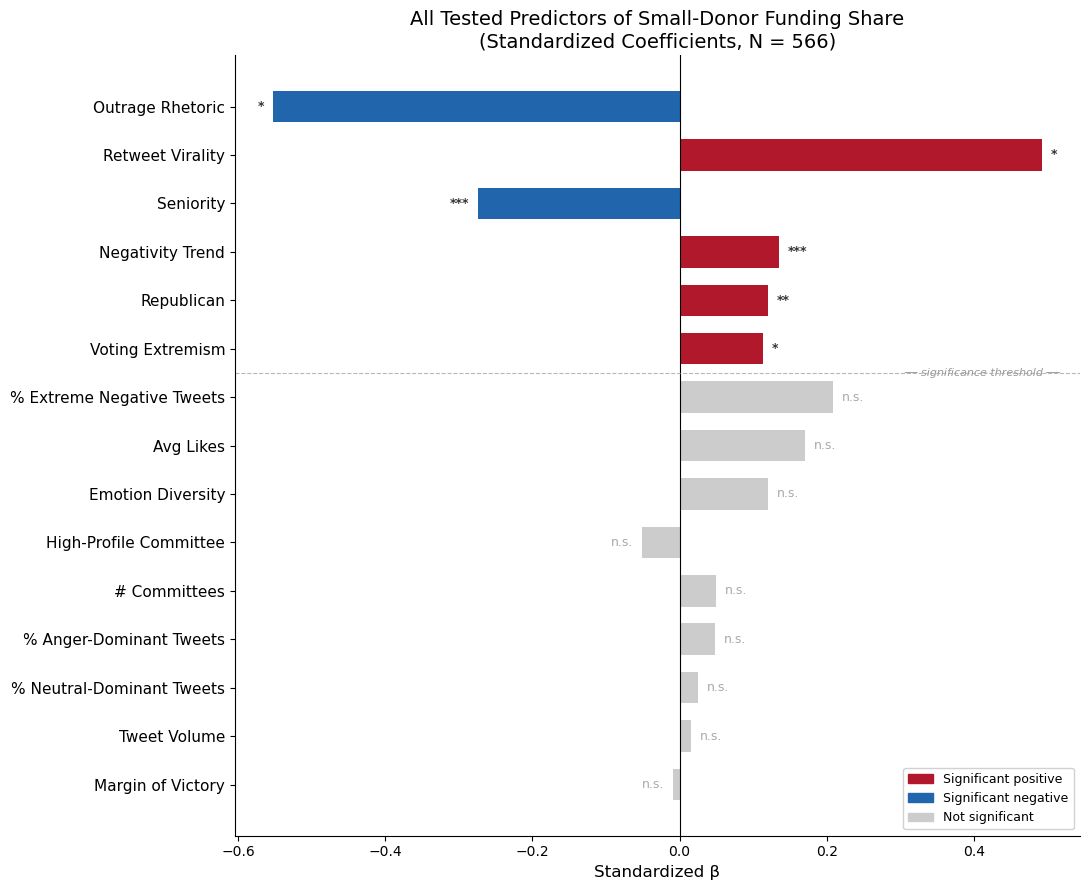

In [97]:
# ── Full coefficient plot: all tested features ────────────────────────────
# Re-run the kitchen sink model standardized

all_vars = ["is_R", "log_avg_retweets", "log_avg_likes", "outrage_index",
            "nominate_abs", "terms_served", "sentiment_slope", "margin_of_victory",
            "log_tweet_count", "on_high_profile", "n_committees",
            "avg_emotion_entropy", "pct_anger_dominant", "pct_neutral_dominant",
            "pct_extreme_neg"]

std_all = user_full[["pct_small_donors"] + all_vars].dropna()
std_all = std_all.apply(zscore)

m_std_all = smf.ols(
    "pct_small_donors ~ " + " + ".join(all_vars),
    data=std_all
).fit()

label_map_full = {
    "is_R": "Republican",
    "log_avg_retweets": "Retweet Virality",
    "log_avg_likes": "Avg Likes",
    "outrage_index": "Outrage Rhetoric",
    "nominate_abs": "Voting Extremism",
    "terms_served": "Seniority",
    "sentiment_slope": "Negativity Trend",
    "margin_of_victory": "Margin of Victory",
    "log_tweet_count": "Tweet Volume",
    "on_high_profile": "High-Profile Committee",
    "n_committees": "# Committees",
    "avg_emotion_entropy": "Emotion Diversity",
    "pct_anger_dominant": "% Anger-Dominant Tweets",
    "pct_neutral_dominant": "% Neutral-Dominant Tweets",
    "pct_extreme_neg": "% Extreme Negative Tweets",
}

params = [p for p in m_std_all.params.index if p != "Intercept"]
betas = [m_std_all.params[p] for p in params]
pvals = [m_std_all.pvalues[p] for p in params]

# Sort: significant first (by |beta|), then non-significant (by |beta|)
sig_idx = [(i, abs(betas[i])) for i in range(len(params)) if pvals[i] < 0.05]
ns_idx = [(i, abs(betas[i])) for i in range(len(params)) if pvals[i] >= 0.05]
sig_idx.sort(key=lambda x: x[1])
ns_idx.sort(key=lambda x: x[1])
order = [i for i, _ in ns_idx] + [i for i, _ in sig_idx]

params_sorted = [params[i] for i in order]
betas_sorted = [betas[i] for i in order]
pvals_sorted = [pvals[i] for i in order]
labels_sorted = [label_map_full[p] for p in params_sorted]

colors = []
for b, p in zip(betas_sorted, pvals_sorted):
    if p >= 0.05:
        colors.append("#cccccc")
    elif b > 0:
        colors.append("#b2182b")
    else:
        colors.append("#2166ac")

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(range(len(params_sorted)), betas_sorted, color=colors, edgecolor="none", height=0.65)
ax.set_yticks(range(len(params_sorted)))
ax.set_yticklabels(labels_sorted, fontsize=11)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized β", fontsize=12)
ax.set_title("All Tested Predictors of Small-Donor Funding Share\n(Standardized Coefficients, N = {})".format(int(m_std_all.nobs)), fontsize=14)

# Divider line between significant and non-significant
n_ns = len(ns_idx)
if n_ns > 0 and n_ns < len(params_sorted):
    ax.axhline(n_ns - 0.5, color="#999999", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.text(ax.get_xlim()[1] * 0.95, n_ns - 0.5, "── significance threshold ──",
            ha="right", va="center", fontsize=8, color="#999999", style="italic")

for i, (beta, p) in enumerate(zip(betas_sorted, pvals_sorted)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    offset = 0.012
    x_pos = beta + offset if beta >= 0 else beta - offset
    ha = "left" if beta >= 0 else "right"
    color = "#333333" if p < 0.05 else "#aaaaaa"
    weight = "bold" if p < 0.05 else "normal"
    ax.text(x_pos, i, sig, va="center", ha=ha, fontsize=9, fontweight=weight, color=color)

pos_patch = mpatches.Patch(color="#b2182b", label="Significant positive")
neg_patch = mpatches.Patch(color="#2166ac", label="Significant negative")
ns_patch = mpatches.Patch(color="#cccccc", label="Not significant")
ax.legend(handles=[pos_patch, neg_patch, ns_patch], loc="lower right", fontsize=9, framealpha=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("all_predictors_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()

In [99]:
feature_cols = ["is_R", "log_avg_retweets", "log_avg_likes", "outrage_index",
                "nominate_abs", "terms_served", "sentiment_slope", "margin_of_victory",
                "log_tweet_count", "avg_emotion_entropy", "pct_anger_dominant",
                "pct_neutral_dominant", "pct_extreme_neg"]

corr = user_full[feature_cols].corr().round(3)

# Show pairs with |r| > 0.5
print("Highly correlated feature pairs (|r| > 0.5):")
print("-" * 55)
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {feature_cols[i]:25s}  ×  {feature_cols[j]:25s}  r = {r:+.3f}")

Highly correlated feature pairs (|r| > 0.5):
-------------------------------------------------------
  log_avg_retweets           ×  log_avg_likes              r = +0.985
  log_avg_retweets           ×  outrage_index              r = +0.705
  log_avg_retweets           ×  pct_anger_dominant         r = +0.681
  log_avg_retweets           ×  pct_extreme_neg            r = +0.628
  log_avg_likes              ×  outrage_index              r = +0.689
  log_avg_likes              ×  pct_anger_dominant         r = +0.664
  log_avg_likes              ×  pct_extreme_neg            r = +0.621
  outrage_index              ×  avg_emotion_entropy        r = +0.702
  outrage_index              ×  pct_anger_dominant         r = +0.956
  outrage_index              ×  pct_extreme_neg            r = +0.938
  avg_emotion_entropy        ×  pct_anger_dominant         r = +0.628
  avg_emotion_entropy        ×  pct_neutral_dominant       r = +0.645
  avg_emotion_entropy        ×  pct_extreme_neg            

In [100]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = user_full[feature_cols].dropna()
vif_results = []
for i, col in enumerate(feature_cols):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = "⚠️" if vif > 5 else "🔴" if vif > 10 else ""
    vif_results.append((col, vif, flag))

vif_results.sort(key=lambda x: x[1], reverse=True)
print(f"{'Feature':<30s}  {'VIF':>8s}")
print("-" * 42)
for col, vif, flag in vif_results:
    print(f"  {col:<28s}  {vif:8.2f}  {flag}")
print()
print("VIF > 5: concerning.  VIF > 10: severe multicollinearity.")

Feature                              VIF
------------------------------------------
  log_avg_likes                   325.61  ⚠️
  avg_emotion_entropy             285.18  ⚠️
  outrage_index                   254.46  ⚠️
  log_avg_retweets                178.69  ⚠️
  log_tweet_count                 123.17  ⚠️
  pct_anger_dominant               85.80  ⚠️
  pct_extreme_neg                  35.47  ⚠️
  pct_neutral_dominant             21.26  ⚠️
  nominate_abs                     20.68  ⚠️
  margin_of_victory                 4.16  
  is_R                              3.14  
  terms_served                      3.03  
  sentiment_slope                   1.40  

VIF > 5: concerning.  VIF > 10: severe multicollinearity.


In [101]:
# VIF for just the parsimonious model features
parsimonious_cols = ["is_R", "log_avg_retweets", "outrage_index", "nominate_abs", "terms_served", "sentiment_slope"]

vif_data = user_full[parsimonious_cols].dropna()
print(f"{'Feature':<30s}  {'VIF':>8s}")
print("-" * 42)
for i, col in enumerate(parsimonious_cols):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = "⚠️" if vif > 5 else "🔴" if vif > 10 else ""
    print(f"  {col:<28s}  {vif:8.2f}  {flag}")

Feature                              VIF
------------------------------------------
  is_R                              2.90  
  log_avg_retweets                  8.81  ⚠️
  outrage_index                    13.76  ⚠️
  nominate_abs                     10.54  ⚠️
  terms_served                      2.46  
  sentiment_slope                   1.28  


In [102]:
# Option A: drop outrage_index
m_no_outrage = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + nominate_abs + terms_served + sentiment_slope",
    data=user_full.dropna(subset=["nominate_abs", "terms_served", "sentiment_slope"])
).fit()

# Option B: drop nominate_abs
m_no_nom = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + outrage_index + terms_served + sentiment_slope",
    data=user_full.dropna(subset=["terms_served", "sentiment_slope"])
).fit()

print(f"Current 6-var:       R² = {m_final.rsquared:.3f}, Adj R² = {m_final.rsquared_adj:.3f}")
print(f"Drop outrage:        R² = {m_no_outrage.rsquared:.3f}, Adj R² = {m_no_outrage.rsquared_adj:.3f}")
print(f"Drop DW-NOMINATE:    R² = {m_no_nom.rsquared:.3f}, Adj R² = {m_no_nom.rsquared_adj:.3f}")

# Check VIFs for each
for label, cols in [("Drop outrage", ["is_R", "log_avg_retweets", "nominate_abs", "terms_served", "sentiment_slope"]),
                     ("Drop DW-NOM", ["is_R", "log_avg_retweets", "outrage_index", "terms_served", "sentiment_slope"])]:
    vif_data = user_full[cols].dropna()
    print(f"\n{label} VIFs:")
    for i, col in enumerate(cols):
        vif = variance_inflation_factor(vif_data.values, i)
        flag = "⚠️" if vif > 5 else ""
        print(f"  {col:<25s}  {vif:.2f}  {flag}")

Current 6-var:       R² = 0.398, Adj R² = 0.391
Drop outrage:        R² = 0.373, Adj R² = 0.367
Drop DW-NOMINATE:    R² = 0.388, Adj R² = 0.382

Drop outrage VIFs:
  is_R                       2.85  
  log_avg_retweets           4.34  
  nominate_abs               8.56  ⚠️
  terms_served               2.44  
  sentiment_slope            1.19  

Drop DW-NOM VIFs:
  is_R                       2.15  
  log_avg_retweets           8.72  ⚠️
  outrage_index              11.18  ⚠️
  terms_served               2.16  
  sentiment_slope            1.16  


In [103]:
m_dim1 = smf.ols(
    "pct_small_donors ~ is_R + log_avg_retweets + nominate_dim1 + terms_served + sentiment_slope",
    data=user_full.dropna(subset=["nominate_dim1", "terms_served", "sentiment_slope"])
).fit()

print(f"With nominate_dim1:  R² = {m_dim1.rsquared:.3f}, Adj R² = {m_dim1.rsquared_adj:.3f}")

cols = ["is_R", "log_avg_retweets", "nominate_dim1", "terms_served", "sentiment_slope"]
vif_data = user_full[cols].dropna()
print("\nVIFs:")
for i, col in enumerate(cols):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = "⚠️" if vif > 5 else ""
    print(f"  {col:<25s}  {vif:.2f}  {flag}")

With nominate_dim1:  R² = 0.370, Adj R² = 0.364

VIFs:
  is_R                       2.42  
  log_avg_retweets           2.56  
  nominate_dim1              1.67  
  terms_served               2.08  
  sentiment_slope            1.49  


In [104]:
# ── Age (from VoteView data already loaded) ──────────────────────────────
vv_age = vv118[vv118["chamber"] == "House"][["bioguide_id", "born"]].rename(columns={"bioguide_id": "bioguide"})
vv_age["age_in_2024"] = 2024 - vv_age["born"]

sample_bio = sample[["handle_lower", "bioguide"]].dropna()
vv_age = vv_age.merge(sample_bio, on="bioguide", how="inner")

user_full = user_full.merge(vv_age[["handle_lower", "age_in_2024"]], on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]

print(f"Age coverage: {user_full['age_in_2024'].notna().sum()}")
print(f"Age range: {user_full['age_in_2024'].min():.0f} – {user_full['age_in_2024'].max():.0f}")
print(f"Mean age: {user_full['age_in_2024'].mean():.1f}")

Age coverage: 921
Age range: 27 – 87
Mean age: 52.1


In [ ]:
# ── Gender (from legislators JSON) ───────────────────────────────────────
import json

with open("/Users/anngo/Documents/GitHub/26-spring-ngo-a/data/main/legislators-current.json") as f:
    current = json.load(f)

gender_data = []
for m in current:
    bid = m["id"].get("bioguide", "")
    gender = m.get("bio", {}).get("gender", "")
    gender_data.append({"bioguide": bid, "gender": gender})

gender_df = pd.DataFrame(gender_data)
gender_df["is_female"] = (gender_df["gender"] == "F").astype(int)

gender_df = gender_df.merge(sample_bio, on="bioguide", how="inner")

user_full = user_full.merge(gender_df[["handle_lower", "is_female"]], on="handle_lower", how="left", suffixes=("", "_dup"))
user_full = user_full[[c for c in user_full.columns if not c.endswith("_dup")]]

print(f"Gender coverage: {user_full['is_female'].notna().sum()}")
print(f"Female members: {user_full['is_female'].sum():.0f} / {user_full['is_female'].notna().sum()}")

FileNotFoundError: [Errno 2] No such file or directory: 'legislators-current.json'